In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy import cos
from math import log
from scipy.interpolate import interp1d
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
from scipy.optimize import fsolve
from sympy import symbols, Eq, solve

In [2]:
cases_data = pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv")

# Convert date columns to datetime
cases_data['date'] = pd.to_datetime(cases_data['date'])

# Filter to study period
start_date = '2017-01-01'
end_date = '2023-12-31'

cases_data = cases_data[
    (cases_data['date'] >= start_date) & 
    (cases_data['date'] <= end_date)
].reset_index(drop=True)

rural_cases_df = cases_data.copy()
rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']] = rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']]*(41.54/100)

#climate_api_data = pd.read_csv("../../data_files/data/climate_api_data_2016_2024.csv")
ibge_rural_pop_data_df_2016_2024 = pd.read_csv("../../data_files/data/ibge_manaus_fixed_rural_population_data_2016_2024.csv")

# Filter between dates
ibge_rural_pop_data_df_2016_2024['index'] = pd.to_datetime(ibge_rural_pop_data_df_2016_2024['index'])

# Create mask
mask = (ibge_rural_pop_data_df_2016_2024['index'] >= '2017-01-01') & (ibge_rural_pop_data_df_2016_2024['index'] <= '2023-12-31')
filtered_df = ibge_rural_pop_data_df_2016_2024[mask]
filtered_df = filtered_df.reset_index().drop(columns=['level_0'])
filtered_df

,index,daily_pop,daily_rural_pop
0,2017-01-01,1.954657e+06,8368.624449
1,2017-01-02,1.954717e+06,8368.328150
2,2017-01-03,1.954776e+06,8368.031851
3,2017-01-04,1.954836e+06,8367.735551
4,2017-01-05,1.954896e+06,8367.439252
...,...,...,...
2551,2023-12-27,2.222621e+06,8041.130218
2552,2023-12-28,2.222840e+06,8041.404876
2553,2023-12-29,2.223059e+06,8041.679533
2554,2023-12-30,2.223279e+06,8041.954190


In [3]:
rural_cases_df

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2017-01-01,944.2042,815.4302,128.7740,0.8308,4530.3524,2017,1,52,1,314.734733
1,2017-01-02,944.6196,815.0148,129.6048,1.6616,4532.0140,2017,1,1,2,188.923920
2,2017-01-03,936.3116,810.4454,125.8662,2.0770,4534.0910,2017,1,1,3,156.051933
3,2017-01-04,928.8344,804.2144,124.6200,0.4154,4534.5064,2017,1,1,4,464.417200
4,2017-01-05,928.4190,803.7990,124.6200,0.0000,4534.5064,2017,1,1,5,928.419000
...,...,...,...,...,...,...,...,...,...,...,...
2551,2023-12-27,461.0940,386.7374,74.3566,1.6616,19699.9296,2023,12,52,361,92.218800
2552,2023-12-28,457.7708,385.0758,72.6950,2.9078,19702.8374,2023,12,52,362,57.221350
2553,2023-12-29,456.1092,385.4912,70.6180,0.8308,19703.6682,2023,12,52,363,152.036400
2554,2023-12-30,451.9552,383.4142,68.5410,0.0000,19703.6682,2023,12,52,364,451.955200


#### Initial testing, based on the parameters used by Parham & Michael (2010). Given that initial conditions weren't given, we will use population and cases from rural Manaus, as per the remainig analysis

In [5]:
if 'active_symptomatic' in rural_cases_df.columns and 'active_asymptomatic' in rural_cases_df.columns:
    # Calculate total infectious cases
    #cases_data['total_infectious'] = cases_data['active_symptomatic'] + cases_data['active_asymptomatic']
    
    # Calculate proportion asymptomatic for model parameter
    rural_cases_df['prop_asymptomatic'] = rural_cases_df['active_asymptomatic'] / rural_cases_df['active_total']
    avg_prop_asymp = rural_cases_df['prop_asymptomatic'].mean()
    print(f"Average proportion asymptomatic: {avg_prop_asymp:.2f}")
    
    # Use total_infectious as I_H
    I_H_data = rural_cases_df['active_total'].values
    I_H0 = I_H_data[0]  # Initial infectious at start date
    
elif 'cumulative_cases' in rural_cases_df.columns:
    # If you only have cumulative cases, calculate new cases per day
    rural_cases_df['new_cases'] = rural_cases_df['cumulative_cases'].diff().fillna(0)
    I_H_data = rural_cases_df['new_cases'].values
    I_H0 = I_H_data[0]
    
else:
    # Fallback: if you only have active cases (as in this case)
    I_H_data = rural_cases_df['active_total'].values
    I_H0 = I_H_data[0]

I_H0 = round(I_H0)

print(f"Initial I_H0: {I_H0}")

Average proportion asymptomatic: 0.12
Initial I_H0: 944


In [6]:
#### Article parameters:

T_prime=19.9

T1=23.2
T2=0.07
omega1=0.67
phi1=1.53

R1=85.9
R2=0.98
omega2=0.65
phi2=1.99

B_E=200
p_ME=0.9
p_ML=0.25
p_MP=0.75
tau_E=1
tau_P=1
c1=0.00554
c2=-0.06737
D1=36.5
b1=0.04
b2=0.09
A=-0.03
B=1.31
C=-4.4
tau_H=10
DD=105
Tmin=14.5
gamma=1/120
R_L=50
N= np.round(filtered_df['daily_rural_pop'].iloc[0])  #8558
M0=1000  # Initial total mosquito population

E_M0=500
#I_H0=1000

if E_M0 is None:
        E_M0 = M0 / 100

S_H0 = N - I_H0
S_M0 = M0 - E_M0

print(f"Initial conditions: N={N}, M0={M0}")
print(f"S_H0={S_H0}, I_H0={I_H0}, R_H0=0")
print(f"S_M0={S_M0}, E_M0={E_M0}, I_M0=0")

Initial conditions: N=8369.0, M0=1000
S_H0=7425.0, I_H0=944, R_H0=0
S_M0=500, E_M0=500, I_M0=0


In [7]:
def Temp(t):
       return T1 * (1 + T2 * cos(omega1 * t - phi1))

def Rain(t):
       return R1 * (1 + R2 * cos(omega2 * t - phi2))

In [8]:
# Global helper functions for mosquito dynamics
# These are used in both the model and visualization

def p(Temp, use_fixed_probs=False):
    """Daily survival probability"""
    denominator = A * Temp**2 + B * Temp + C
    if use_fixed_probs:
        if denominator <= 0:
            return 0.0
        return np.exp(-1.0 / denominator)
    return np.exp(-1.0 / denominator)

def tau_L(Temp, use_fixed_probs=False):
    """Larval development time (days)"""
    denominator = c1 * Temp + c2
    if use_fixed_probs:
        if denominator <= 0:
            return np.inf
        return 1.0 / denominator
    return 1.0 / denominator

def p_LT(Temp):
    """Temperature-dependent larval survival"""
    return np.exp(-(c1 * Temp + c2))

def p_LR(Rain, use_fixed_probs=False):
    """Rainfall-dependent larval survival"""
    value = (4 * p_ML / R_L**2) * Rain * (R_L - Rain)
    if use_fixed_probs:
        return np.maximum(0, value) # Prevent negative values
    return value  

def p_LRT(Rain, Temp, use_fixed_probs=False):
    """Combined larval survival"""
    return p_LR(Rain, use_fixed_probs) * p_LT(Temp)

def p_ER(Rain, use_fixed_probs=False):
    """Rainfall-dependent egg survival"""
    value = (4 * p_ME / R_L**2) * Rain * (R_L - Rain)
    if use_fixed_probs:
        return np.maximum(0, value) # Prevent negative values
    return value  

def p_PR(Rain, use_fixed_probs=False):
    """Rainfall-dependent pupal survival"""
    value = (4 * p_MP / R_L**2) * Rain * (R_L - Rain)
    if use_fixed_probs:
        return np.maximum(0, value) # Prevent negative values
    return value  

def mu(Temp, use_fixed_probs=False):
    """Mosquito mortality rate (per day)"""
    p_val = p(Temp, use_fixed_probs)
    if use_fixed_probs:
        if p_val <= 0:
            return np.inf
        return -np.log(p_val)
    return -np.log(p_val)

def b(Rain, Temp, use_fixed_probs=False):
    """Mosquito birth rate (per day)"""
    return B_E * p_ER(Rain) * p_LRT(Rain, Temp, use_fixed_probs) * p_PR(Rain) / (tau_E + tau_L(Temp, use_fixed_probs) + tau_P)

def a(Temp, Rain, use_fixed_probs=False):
    """Biting rate (bites per mosquito per day)"""
    a_val = (Temp - T_prime) / D1
    if use_fixed_probs:
        return np.maximum(0, a_val)
    return a_val

def tau_M(Temp, use_fixed_probs=False):
    """Mosquito development time (days)"""
    if use_fixed_probs:
        diff = Temp - Tmin
        if diff <= 0:
            return np.inf
        return DD / diff
    return DD / (Temp - Tmin)

print("Helper functions defined globally (fixed negative birth rate).")


Helper functions defined globally (fixed negative birth rate).


In [9]:
def original_model(t, z, history, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
                   D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
                   N, M0, use_fixed_probs=False): 

    S_H, I_H, R_H, S_M, E_M, I_M = z
    M = S_M + E_M + I_M  # Total mosquito population (dynamic)

    # Get the closest integer day
    day_index = int(t)
    
    T_curr = Temp(day_index)
    R_curr = Rain(day_index)

    # ============================================================
    # Use global helper functions with use_fixed_probs parameter
    # ============================================================

    tau_M_curr = tau_M(T_curr, use_fixed_probs)
    l_curr = p(T_curr, use_fixed_probs)**tau_M_curr
    mu_curr = mu(T_curr, use_fixed_probs)
    a_curr = a(T_curr, R_curr, use_fixed_probs)
    b_curr = b(R_curr, T_curr, use_fixed_probs)

    # ----- DELAYED STATES -----

    S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = history(t - tau_H)
    S_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = history(t - tau_M_curr)

    # ----- HUMAN EQUATIONS -----

    dShdt = -a_curr * b2 * (I_M / N) * S_H

    dIhdt = (
        a_curr * b2 * (I_M_delay / N) * S_H_delay
        - gamma * I_H
    )

    dRhdt = gamma * I_H

    # ----- MOSQUITO EQUATIONS -----

    # Total mosquito population dynamics: dM/dt = b(t) - μ(t)M
    # M = S_M + E_M + I_M (tracked dynamically)

    dSmdt = b_curr - a_curr * b1 * (I_H / N) * S_M - mu_curr * S_M

    dEmdt = (
        a_curr * b1 * (I_H / N) * S_M
        - a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr
        - mu_curr * E_M
    )

    dImdt = (
        a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr
        - mu_curr * I_M
    )

    return [dShdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [10]:
initial_state = np.array([S_H0, I_H0, 0, S_M0, E_M0, 0])

In [11]:
def history(t):
    return initial_state

In [12]:
args = (history, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
        D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
        N, M0, True)

In [13]:
t_eval = np.arange(0, 365, 0.1)  # 0.1 day steps

sol = solve_ivp(
    original_model,
    [0, 365],
    initial_state,
    args=args,
    dense_output=True,
    t_eval=t_eval,
    method="LSODA" #"DOP853"
)

In [14]:
def history(t):
    if t <= 0:
        return initial_state
    return sol.sol(t)

In [15]:
times = sol.t
S_H, I_H, R_H, S_M, E_M, I_M = sol.y
M_total_true = S_M + E_M + I_M  # Total mosquito population M(t)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


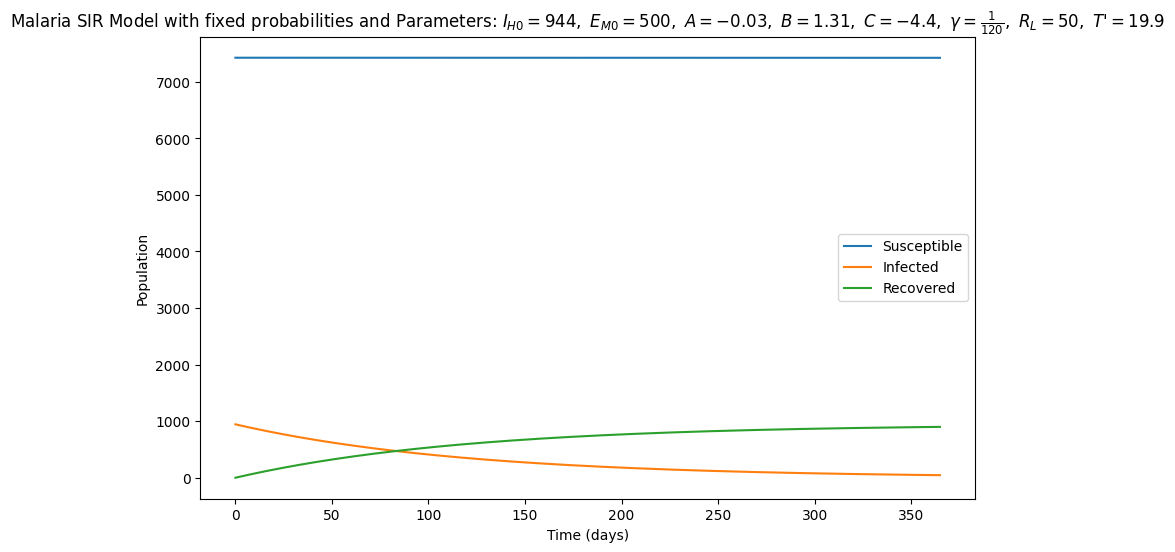

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_H, label='Susceptible')
plt.plot(times, I_H, label='Infected')
plt.plot(times, R_H, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(
    rf"Malaria SIR Model with fixed probabilities and Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()
plt.show()

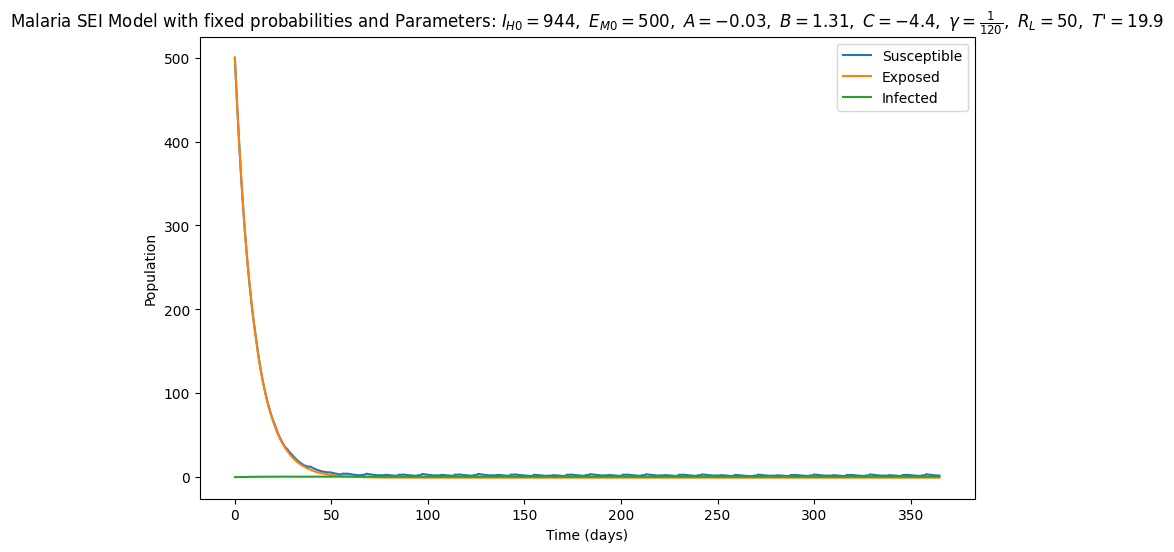

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_M, label='Susceptible')
plt.plot(times, E_M, label='Exposed')
plt.plot(times, I_M, label='Infected')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(rf"Malaria SEI Model with fixed probabilities and Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()
plt.show()

In [18]:
args = (history, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
        D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
        N, M0, False)

t_eval = np.arange(0, 365, 0.1)  # 0.1 day steps

sol = solve_ivp(
    original_model,
    [0, 365],
    initial_state,
    args=args,
    dense_output=True,
    t_eval=t_eval,
    method="LSODA" #"DOP853"
)

def history(t):
    if t <= 0:
        return initial_state
    return sol.sol(t)

times = sol.t

S_H, I_H, R_H, S_M, E_M, I_M = sol.y
M_total_false = S_M + E_M + I_M  # Total mosquito population M(t)

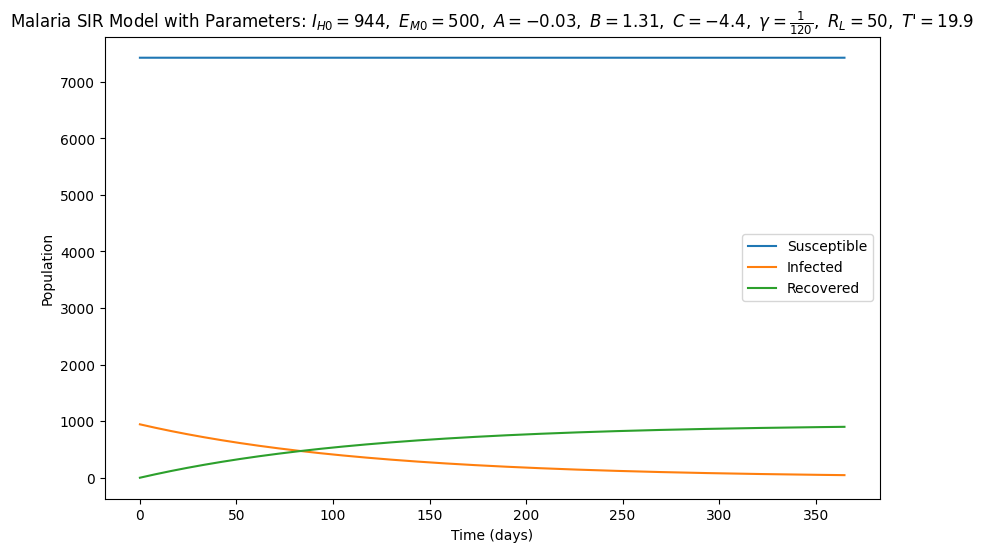

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_H, label='Susceptible')
plt.plot(times, I_H, label='Infected')
plt.plot(times, R_H, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(
    rf"Malaria SIR Model with Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()
plt.show()

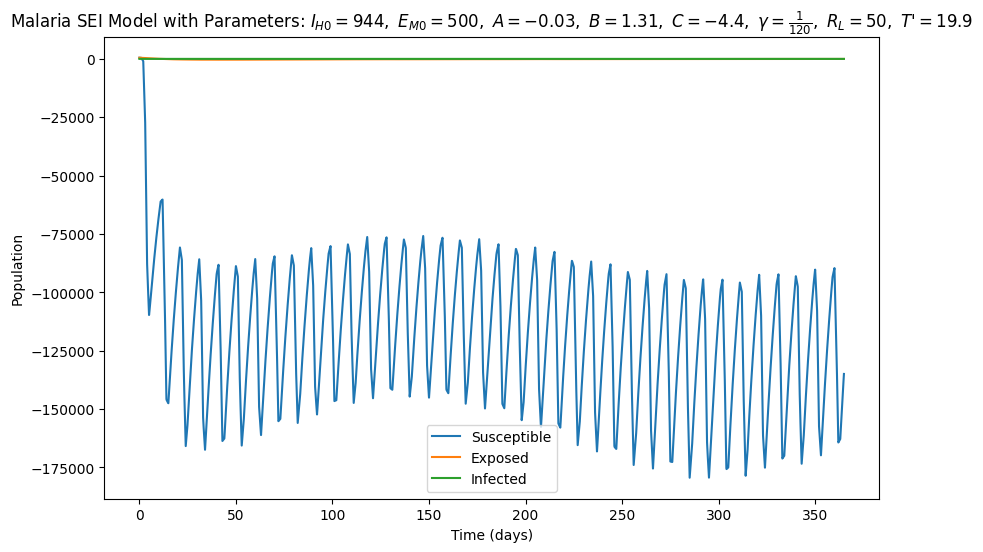

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_M, label='Susceptible')
plt.plot(times, E_M, label='Exposed')
plt.plot(times, I_M, label='Infected')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(rf"Malaria SEI Model with Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()
plt.show()

#### Mosquito Population Dynamics

The deterministic model for the vector population is given by:

$$\frac{dM}{dt} = b(t) - \mu(t) M(t) \quad \text{(7)}$$

where:
- $M(t) = S_M(t) + E_M(t) + I_M(t)$ is the total mosquito population
- $b(t)$ is the mosquito birth rate (temperature and rainfall dependent)
- $\mu(t)$ is the mosquito mortality rate (temperature dependent)

In the stochastic formulation, if $p_M(t)$ denotes the probability of having $M(t)$ mosquitoes at time $t$, the master equation is:

$$\frac{dp_M(t)}{dt} = b(t)p_{M-1}(t) - b(t)p_M(t) + (M+1)\mu(t)p_{M+1}(t) - M\mu(t)p_M(t) \quad \text{(8)}$$

For this deterministic model, we use the mean values of environmental factors (temperature and rainfall) to drive the mosquito population dynamics.

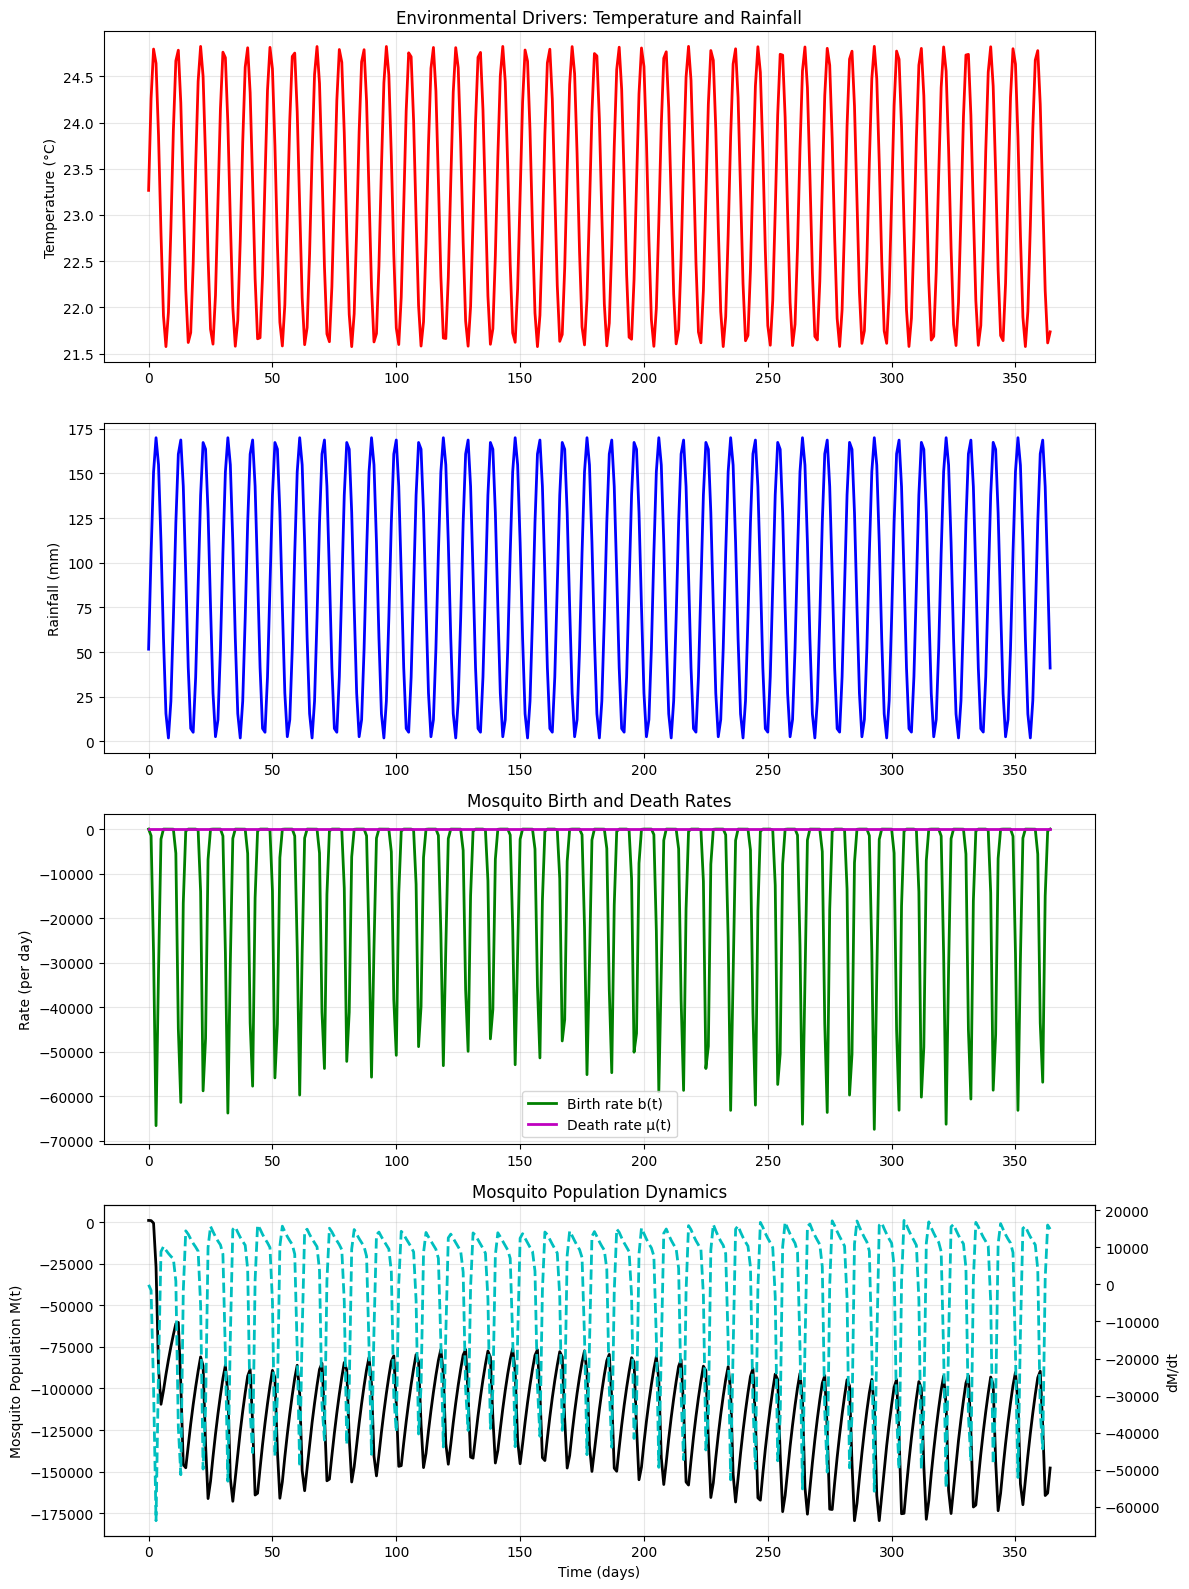

Steady-state M (b/μ ratio): -122332.9
Mean M(t) over simulation: -118948.8
Mean birth rate b(t): -12497.0018
Mean death rate μ(t): 0.1020


In [22]:
# Calculate environmental drivers and rates over time
t_vals = np.arange(0, 365, 1)
T_vals = np.array([Temp(t) for t in t_vals])
R_vals = np.array([Rain(t) for t in t_vals])
b_vals = np.array([b(Rain(t), Temp(t), False) for t in t_vals])
mu_vals = np.array([mu(Temp(t), False) for t in t_vals])

# Interpolate M_total to match t_vals
M_interp = np.interp(t_vals, times, M_total_false)

# Calculate dM/dt = b(t) - mu(t)*M(t)
dM_dt = b_vals - mu_vals * M_interp

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

# Temperature
axes[0].plot(t_vals, T_vals, 'r-', linewidth=2)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Environmental Drivers: Temperature and Rainfall')
axes[0].grid(True, alpha=0.3)

# Rainfall
axes[1].plot(t_vals, R_vals, 'b-', linewidth=2)
axes[1].set_ylabel('Rainfall (mm)')
axes[1].grid(True, alpha=0.3)

# Birth and death rates
axes[2].plot(t_vals, b_vals, 'g-', linewidth=2, label='Birth rate b(t)')
axes[2].plot(t_vals, mu_vals, 'm-', linewidth=2, label='Death rate μ(t)')
axes[2].set_ylabel('Rate (per day)')
axes[2].set_title('Mosquito Birth and Death Rates')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Mosquito population and dM/dt
ax2_twin = axes[3].twinx()
axes[3].plot(t_vals, M_interp, 'k-', linewidth=2, label='M(t)')
ax2_twin.plot(t_vals, dM_dt, 'c--', linewidth=2, label='dM/dt')
axes[3].set_xlabel('Time (days)')
axes[3].set_ylabel('Mosquito Population M(t)')
ax2_twin.set_ylabel('dM/dt')
axes[3].set_title('Mosquito Population Dynamics')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Steady-state M (b/μ ratio): {np.mean(b_vals/mu_vals):.1f}")
print(f"Mean M(t) over simulation: {np.mean(M_total_false):.1f}")
print(f"Mean birth rate b(t): {np.mean(b_vals):.4f}")
print(f"Mean death rate μ(t): {np.mean(mu_vals):.4f}")

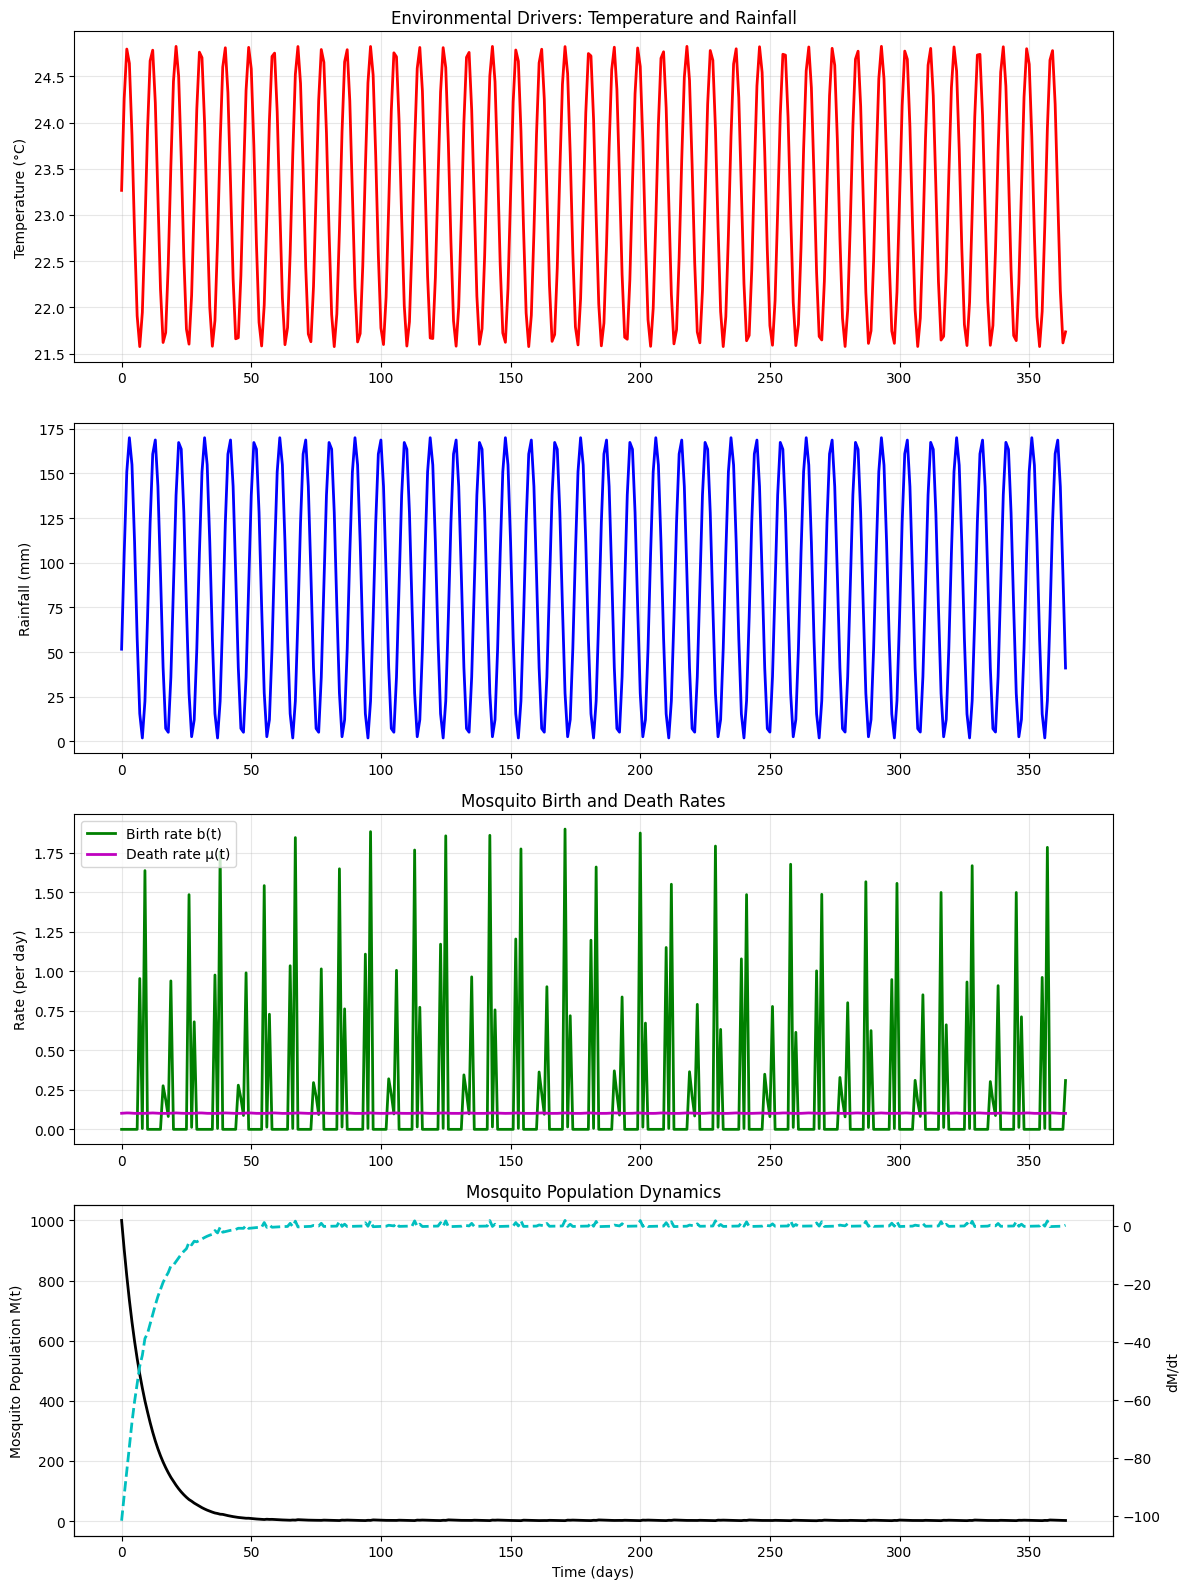

Steady-state M (b/μ ratio): 2.2
Mean M(t) over simulation: 29.1
Mean birth rate b(t): 0.2268
Mean death rate μ(t): 0.1020


In [23]:
# Calculate environmental drivers and rates over time
t_vals = np.arange(0, 365, 1)
T_vals = np.array([Temp(t) for t in t_vals])
R_vals = np.array([Rain(t) for t in t_vals])
b_vals = np.array([b(Rain(t), Temp(t), True) for t in t_vals])
mu_vals = np.array([mu(Temp(t), True) for t in t_vals])

# Interpolate M_total to match t_vals
M_interp = np.interp(t_vals, times, M_total_true)

# Calculate dM/dt = b(t) - mu(t)*M(t)
dM_dt = b_vals - mu_vals * M_interp

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

# Temperature
axes[0].plot(t_vals, T_vals, 'r-', linewidth=2)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Environmental Drivers: Temperature and Rainfall')
axes[0].grid(True, alpha=0.3)

# Rainfall
axes[1].plot(t_vals, R_vals, 'b-', linewidth=2)
axes[1].set_ylabel('Rainfall (mm)')
axes[1].grid(True, alpha=0.3)

# Birth and death rates
axes[2].plot(t_vals, b_vals, 'g-', linewidth=2, label='Birth rate b(t)')
axes[2].plot(t_vals, mu_vals, 'm-', linewidth=2, label='Death rate μ(t)')
axes[2].set_ylabel('Rate (per day)')
axes[2].set_title('Mosquito Birth and Death Rates')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Mosquito population and dM/dt
ax2_twin = axes[3].twinx()
axes[3].plot(t_vals, M_interp, 'k-', linewidth=2, label='M(t)')
ax2_twin.plot(t_vals, dM_dt, 'c--', linewidth=2, label='dM/dt')
axes[3].set_xlabel('Time (days)')
axes[3].set_ylabel('Mosquito Population M(t)')
ax2_twin.set_ylabel('dM/dt')
axes[3].set_title('Mosquito Population Dynamics')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Steady-state M (b/μ ratio): {np.mean(b_vals/mu_vals):.1f}")
print(f"Mean M(t) over simulation: {np.mean(M_total_true):.1f}")
print(f"Mean birth rate b(t): {np.mean(b_vals):.4f}")
print(f"Mean death rate μ(t): {np.mean(mu_vals):.4f}")

#### Extinction Probability from Probability Generating Function

The extinction probability is $p_0(t) = G(0, t)$ - the probability that the mosquito population goes extinct at time $t$.

From the PDE (9):
$$\frac{\partial G}{\partial t} = b(t)(z-1)G + \mu(t)(1-z^{-1})G$$

We can solve this numerically to find $G(z,t)$ and thus $p_0(t) = G(0,t)$.

For constant rates, the extinction probability from initial population $M_0$ is:
- If $b < \mu$: $p_{ext} = 1$ (certain extinction)
- If $b > \mu$: $p_{ext} = (\mu/b)^{M_0}$ (probabilistic)

For time-dependent rates, we solve the full PDE numerically.

In [25]:
# Extinction Probability from Stochastic Model
# For a birth-death process with time-dependent rates,
# the extinction probability p₀(t) can be approximated.

# Method: Use the quasi-steady approximation
# At each time t, if b(t) < μ(t), extinction is certain
# If b(t) > μ(t), p_ext(t) = (μ(t)/b(t))^M(t)
# where M(t) is the current population from deterministic model

def extinction_probability(M_t, b_t, mu_t):
    """Compute extinction probability given current state"""
    if b_t <= 0:
        return 1.0  # No births, extinction certain
    ratio = mu_t / b_t
    if ratio >= 1:
        return 1.0  # Deaths exceed births
    return min(1.0, ratio**M_t)  # Probability of extinction

# Calculate extinction probability over time using deterministic solution
t_vals = np.arange(0, 365, 1)
p_ext = []

for t in t_vals:
    b_t = b(Rain(int(t)), Temp(int(t)))
    mu_t = mu(Temp(int(t)))
    M_t = np.interp(t, times, M_total)  # Interpolate M(t) from simulation
    p_ext.append(extinction_probability(int(M_t), b_t, mu_t))

p_ext = np.array(p_ext)

# Plot extinction probability
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Extinction probability over time
axes[0].plot(t_vals, p_ext, 'r-', linewidth=2)
axes[0].axhline(y=1.0, color='k', linestyle=':', alpha=0.5, label='Certain extinction')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Extinction Probability p₀(t)')
axes[0].set_title('Mosquito Population Extinction Probability')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: b(t) vs μ(t) ratio
b_vals = np.array([b(Rain(int(t)), Temp(int(t))) for t in t_vals])
mu_vals = np.array([mu(Temp(int(t))) for t in t_vals])
ratio = b_vals / mu_vals

axes[1].plot(t_vals, ratio, 'b-', linewidth=2, label='b(t)/μ(t)')
axes[1].axhline(y=1.0, color='r', linestyle='--', label='b=μ threshold')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('b(t)/μ(t)')
axes[1].set_title('Birth/Death Rate Ratio (extinction if < 1)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean extinction probability: {np.mean(p_ext):.4f}")
print(f"Max extinction probability: {np.max(p_ext):.4f}")
print(f"Min extinction probability: {np.min(p_ext):.4f}")
print(f"\nDays with certain extinction (p=1): {np.sum(p_ext >= 0.9999)}")
print(f"Days with low extinction risk (p<0.1): {np.sum(p_ext < 0.1)}")

NameError: name 'M_total' is not defined